# Creating Cohorts of Songs 

## Problem Scenario

The customer always looks forward to specialized treatment, whether shopping on an e-commerce website or watching Netflix. The customer desires content that aligns with their preferences. To maintain customer engagement, companies must consistently provide the most relevant information. 

Starting with Spotify, a Swedish audio streaming and media service provider, boasts over 456 million active monthly users, including more than 195 million paid subscribers as of September 2022. The company aims to create cohorts of different songs to enhance song recommendations. These cohorts will be based on various relevant features, ensuring that each group contains similar types of songs. 

### Problem Objective: 

As a data scientist, you should perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.

**Input dataset:** [song_data](https://drive.google.com/file/d/1IWlXWFi-0_toy_epV3-_95ciy12C-Sx6/view?usp=drive_link)

### Data Description: 

The dataset comprises information from Spotify's API regarding all albums by the Rolling Stones available on Spotify. It's crucial to highlight that each song possesses a unique ID. 

| Variable | Description |
|----------|-------------|
| name | It is the name of the song. |
| album | It is the name of the album. |
| release_date | It is the day, month, and year the album was released. |
| track number | It is the order in which the song appears on the album. |
| id | It is the Spotify ID for the song. |
| uri | It is the Spotify URI for the song. |
| acousticness | A confidence measure from 0.0 to 1.0 indicates whether the track is acoustic. 1.0 represents high confidence that the track is acoustic. |
| danceability | It describes how suitable a track is for dancing based on a combination of musical elements, including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is the least danceable, and 1.0 is the most danceable. |
| energy | It is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. |
| instrumentalness | It predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal." The closer the instrumentalness value is to 1.0, the greater the likelihood that the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. |
| liveness | It detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides a strong likelihood that the track is live. |
| loudness | The overall loudness of a track in decibels (dB) and loudness values are averaged across the entire track and are useful for comparing the relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 dB. |
| speechiness | It detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g., talk show, audiobook, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. |
| tempo | The overall estimated tempo of a track is measured in beats per minute (BPM). In musical terminology, the tempo is the speed or pace of a given piece and derives directly from the average beat duration. |
| valence | A measure from 0.0 to 1.0 describes the musical positivity conveyed by a track. Tracks with high valence sound more positive (e.g., happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, angry). |
| popularity | The popularity of the song ranges from 0 to 100. |
| duration_ms | It is the duration of the track in milliseconds. |

### Steps to Perform: 

**Initial data inspection and data cleaning:** 

- Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed 
- Refine the data for further processing based on your findings 

**Perform exploratory data analysis and feature engineering** 

- Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album 
- Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns 
- Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved 
- Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations

**Perform cluster analysis** 

- Identify the right number of clusters 
- Use appropriate clustering algorithms 
- Define each cluster based on the features


In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [13]:
# Pull in our song data csv into a dataframe
song_df = pd.read_csv('rolling_stones_spotify.csv')

# Display the first few rows of the dataframe
print(song_df.shape)
print(song_df.head())
print(song_df.info())
print(song_df.describe())
# print(song_df.isnull().sum()) # No missing/null data found

(1610, 18)
   Unnamed: 0                         name               album release_date  \
0           0   Concert Intro Music - Live  Licked Live In NYC   2022-06-10   
1           1   Street Fighting Man - Live  Licked Live In NYC   2022-06-10   
2           2           Start Me Up - Live  Licked Live In NYC   2022-06-10   
3           3  If You Can't Rock Me - Live  Licked Live In NYC   2022-06-10   
4           4            Don’t Stop - Live  Licked Live In NYC   2022-06-10   

   track_number                      id                                   uri  \
0             1  2IEkywLJ4ykbhi1yRQvmsT  spotify:track:2IEkywLJ4ykbhi1yRQvmsT   
1             2  6GVgVJBKkGJoRfarYRvGTU  spotify:track:6GVgVJBKkGJoRfarYRvGTU   
2             3  1Lu761pZ0dBTGpzxaQoZNW  spotify:track:1Lu761pZ0dBTGpzxaQoZNW   
3             4  1agTQzOTUnGNggyckEqiDH  spotify:track:1agTQzOTUnGNggyckEqiDH   
4             5  7piGJR8YndQBQWVXv6KtQw  spotify:track:7piGJR8YndQBQWVXv6KtQw   

   acousticness  danceabili

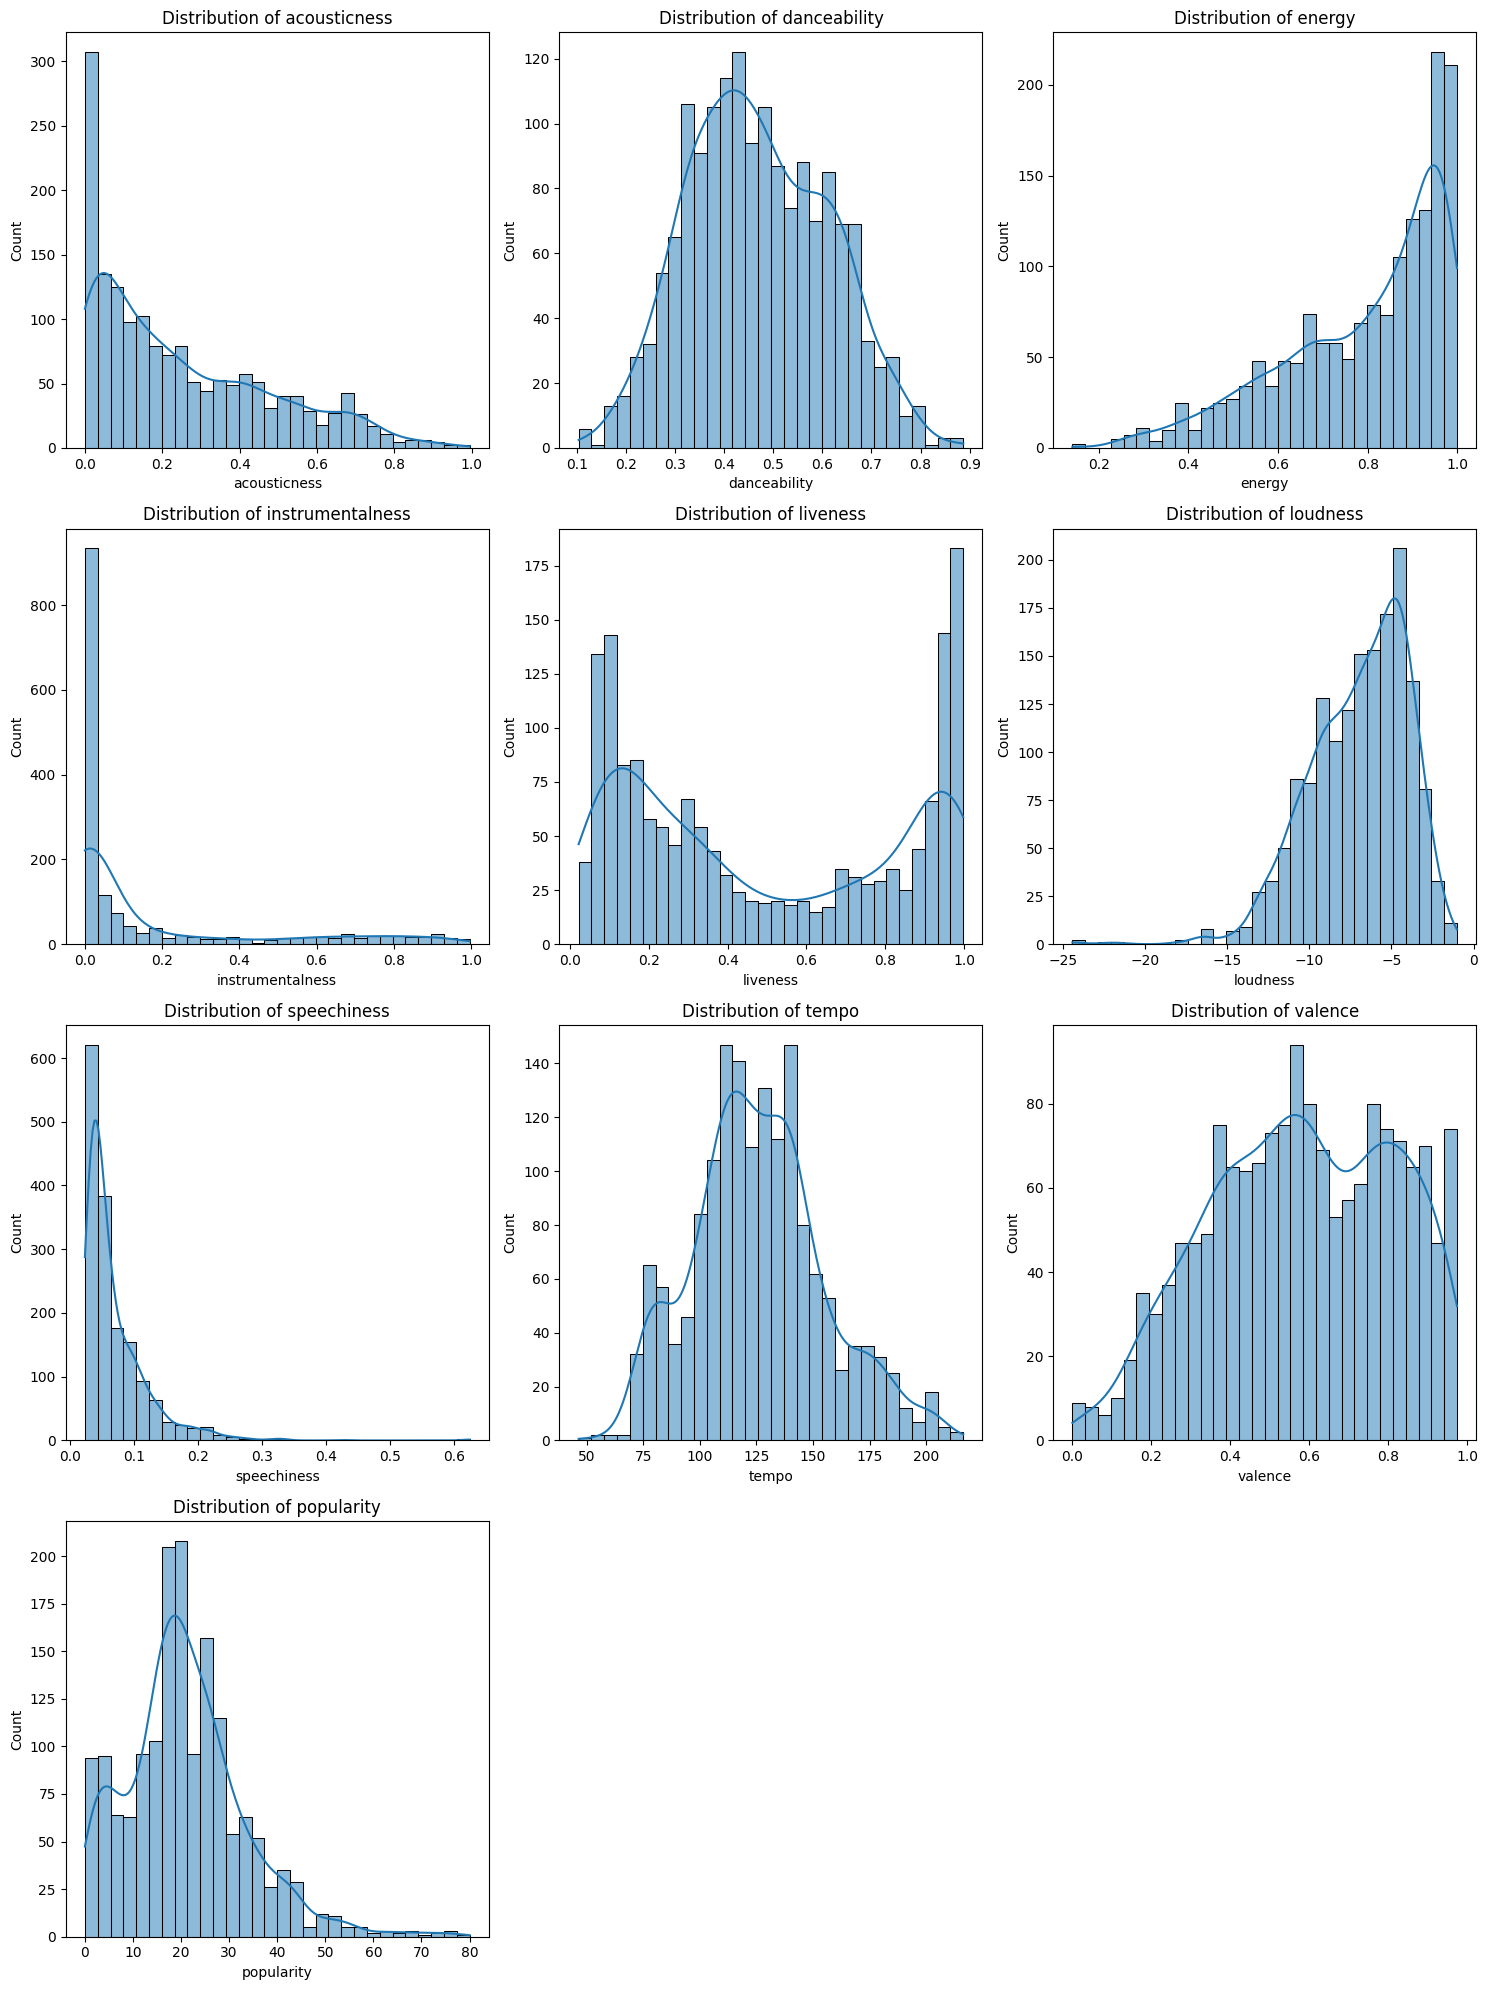

In [14]:
# Exploratory Data Analysis (EDA)
# Remove the 'Unnamed: 0' column
song_df = song_df.drop(columns=['Unnamed: 0'])
# remove columns that have useless information for cohort clustering
song_df = song_df.drop(columns=['uri', 'track_number', 'name', 'album', 'duration_ms'])

def plot_feature_distributions(df):
    features = df.select_dtypes(include=[np.number]).columns.tolist()
    num_features = len(features)
    cols = 3
    # Calculate number of rows needed
    rows = (num_features // cols) + (num_features % cols > 0)
    
    plt.figure(figsize=(15, 5 * rows))
    for i, feature in enumerate(features):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
    plt.tight_layout()
    plt.show()

plot_feature_distributions(song_df)

## Notes so far
- 